

<span style="font-size: 24px;">Datamining Final Project</span>
>


<span style="font-size: 16px;"> Amirhossein Karimzadgan - 40121833</span>

<span style="font-size: 14px;"> In this project, we use the Spambase dataset from the following link:
https://archive.ics.uci.edu/dataset/94/spambase</span>

First, we explore the details of this dataset:

- We find out how many features this dataset has:

In [4]:
import pandas as pd

file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"

data = pd.read_csv(file_path, header=None)

# Number of features (excluding the target variable)
num_features = data.shape[1] - 1  # Last column is the target variable
print(f"Number of features: {num_features}")

Number of features: 57


- We give a brief explanation about the features:

The UCI Spambase dataset contains 57 continuous real attributes and 1 binary class label (0 for non-spam, 1 for spam). <br> 
A brief description about the features:<br>

48 continuous features indicating the frequency of occurrence of certain words. <br>
6 continuous features indicating the frequency of occurrence of certain characters. <br>
1 continuous feature indicating the average length of uninterrupted sequences of capital letters. <br>
1 continuous feature indicating the length of the longest uninterrupted sequence of capital letters. <br>
1 continuous feature indicating the total number of capital letters.

- We determine the relationship between the features and the target variable:

For this, we use the absolute value of the correlation between each feature and the target variable, and also the variance of each feature. <br>
The higher the correlation between each feature and the target variable, the more informative the feature is. <br>
The higher the variance, the more informative each feature is. <br>
<br>
The reason we use the absolute value of the correlation between features and the target variable is that we care about the strangth of the correlation, regardless of its direction (positive or negative). <br>
<br>
The reason we use variance is because high variance indicates that the feature can differentiate between different data points more effectively. Features with low variance may not provide much information because they do not vary much across the data points and hence may not contribute significantly to distinguishing between different classes or making accurate predictions. Variance can help in distinguishing between signal (useful information) and noise (random variability). Features with low variance are more likely to be noise, while those with higher variance are more likely to contain useful information.

Informative Features:
       Feature  Correlation       Variance  AbsCorrelation  LogVariance
20  feature_20     0.383234       1.441944        0.383234     0.892795
22  feature_22     0.334787       0.122701        0.334787     0.115737
6    feature_6     0.332117       0.153226        0.332117     0.142564
18  feature_18     0.273651       3.152332        0.273651     1.423670
15  feature_15     0.263215       0.681932        0.263215     0.519943
16  feature_16     0.263204       0.197185        0.263204     0.179973
24  feature_24    -0.256723       2.793409        0.256723     1.333265
56  feature_56     0.249164  367657.716079        0.249164    12.814910
4    feature_4     0.241920       0.452273        0.241920     0.373130
51  feature_51     0.241888       0.665320        0.241888     0.510017
25  feature_25    -0.232968       0.786690        0.232968     0.580365
23  feature_23     0.216111       0.195926        0.216111     0.178921
55  feature_55     0.216097   37982.622529

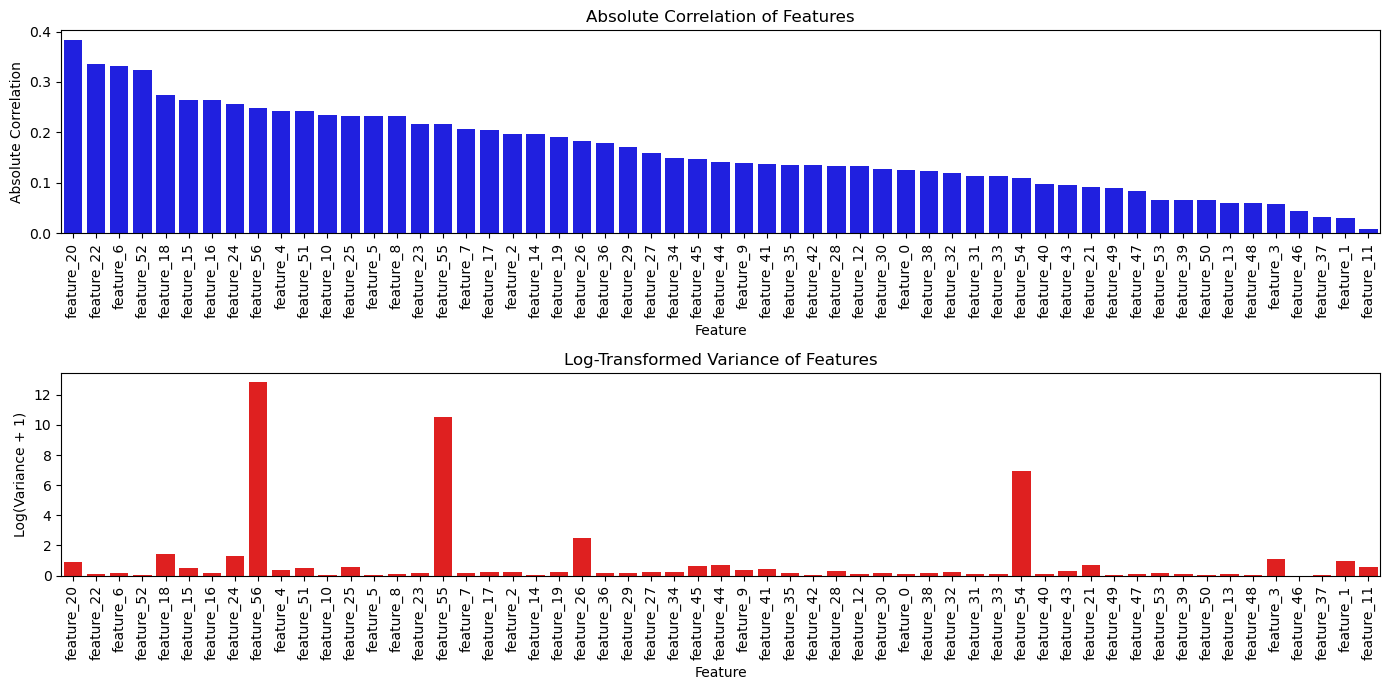

In [5]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"

# Load the data into a DataFrame
column_names = [f"feature_{i}" for i in range(57)] + ["target"] 
data = pd.read_csv(file_path, header=None, names=column_names)

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Correlation with the target variable
target_correlation = correlation_matrix["target"].iloc[:-1]  # Exclude the target column itself

# Calculate the variance of each feature
feature_variances = data.var().iloc[:-1]  # Exclude the target column

# Combine correlation and variance into a single DataFrame
feature_stats = pd.DataFrame({
    'Feature': column_names[:-1],
    'Correlation': target_correlation.values,
    'Variance': feature_variances.values
})

# Sort features by absolute correlation and variance
feature_stats['AbsCorrelation'] = feature_stats['Correlation'].abs()
feature_stats = feature_stats.sort_values(by=['AbsCorrelation', 'Variance'], ascending=False)

# Apply logarithmic transformation to the variance
feature_stats['LogVariance'] = np.log1p(feature_stats['Variance'])

# Define thresholds
correlation_threshold = 0.1
variance_threshold = feature_stats['Variance'].quantile(0.25)

# Separate informative and non-informative features
informative_features = feature_stats[(feature_stats['AbsCorrelation'] >= correlation_threshold) & (feature_stats['Variance'] >= variance_threshold)]
non_informative_features = feature_stats[(feature_stats['AbsCorrelation'] < correlation_threshold) | (feature_stats['Variance'] < variance_threshold)]

print("Informative Features:")
print(informative_features)

print("\nNon-Informative Features:")
print(non_informative_features)

# Plot the statistics with log-transformed variance
plt.figure(figsize=(14, 7))

# Absolute Correlation Plot
plt.subplot(2, 1, 1)
sns.barplot(x='Feature', y='AbsCorrelation', data=feature_stats, color='b')
plt.ylabel("Absolute Correlation")
plt.title("Absolute Correlation of Features")
plt.xticks(rotation=90)

# Log-Variance Plot
plt.subplot(2, 1, 2)
sns.barplot(x='Feature', y='LogVariance', data=feature_stats, color='r')
plt.ylabel("Log(Variance + 1)")
plt.title("Log-Transformed Variance of Features")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


- We divide the dataset into a training set and a test set:

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split #ok 

file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"

column_names = [f"feature_{i}" for i in range(57)] + ["target"]  
data = pd.read_csv(file_path, header=None, names=column_names)

# Split the data into training and testing sets
X = data.drop("target", axis=1)
y = data["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


- We train then test the KNN algorithm:

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time


file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"


data = pd.read_csv(file_path, header=None)

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into training and test sets
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define a function for the weighted majority vote
def weighted_majority_vote(distances, indices, k):
    weights = np.zeros_like(distances)
    for i, distance in enumerate(distances):
        if distance == 0:
            weights[i] = 1e5  # Assign a very high weight if distance is zero
        else:
            weights[i] = 1 / np.square(distance) # Weight is 1/d^2
    weighted_votes = np.zeros(np.max(y_train) + 1)
    for i in range(k):
        weighted_votes[y_train[indices[i]]] += weights[i]
    return np.argmax(weighted_votes)

# Define a function to compute the Euclidian distance between two points
def compute_distances(X_train, x):
    distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    return distances

# Define the KNN algorithm
def knn(X_train, y_train, X_test, k):
    y_pred = []
    for x in X_test:
        distances = compute_distances(X_train, x)
        indices = np.argsort(distances)[:k]
        k_nearest_distances = distances[indices]
        y_pred.append(weighted_majority_vote(k_nearest_distances, indices, k))
    return np.array(y_pred)

# Cross-validation to find the best k
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_k = None
best_score = 0

for k in range(1, 31):
    scores = []
    for train_index, val_index in kf.split(X_train):
        X_train_cv, X_val_cv = X_train[train_index], X_train[val_index]
        y_train_cv, y_val_cv = y_train[train_index], y_train[val_index]
        y_val_pred = knn(X_train_cv, y_train_cv, X_val_cv, k)
        scores.append(accuracy_score(y_val_cv, y_val_pred))
    avg_score = np.mean(scores)
    if avg_score > best_score:
        best_score = avg_score
        best_k = k


start_train_time = time.time()
# Storing training data 
X_train_stored = X_train
y_train_stored = y_train
train_time = time.time() - start_train_time

# Calculate the training error using the training set itself
start_test_time = time.time()
y_train_pred = knn(X_train_stored, y_train_stored, X_train_stored, best_k)
train_error = 1 - accuracy_score(y_train_stored, y_train_pred)
test_time_train_set = time.time() - start_test_time

# Test the KNN model
start_test_time = time.time()
y_test_pred = knn(X_train_stored, y_train_stored, X_test, best_k)
test_time = time.time() - start_test_time

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Output the results
print("Best k:", best_k)
print("Training error:", train_error)
print(f"Training time: {train_time:.6f} seconds") 
print("Test time:", test_time , "seconds")
print("Test accuracy:", test_accuracy)


Best k: 27
Training error: 0.0009316770186335033
Training time: 0.000000 seconds
Test time: 1.8636670112609863 seconds
Test accuracy: 0.9246922519913107


- We train then test the Decision Tree algorithm:

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time

file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"
data = pd.read_csv(file_path, header=None)

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Function to calculate Gini index
def gini_index(y):
    classes, counts = np.unique(y, return_counts=True)
    proportions = counts / len(y)
    return 1 - np.sum(proportions ** 2)

# Function to find best split for a node
def find_best_split(X, y, n_thresholds=10):
    best_gini = float('inf')
    best_feature = None
    best_threshold = None
    
    n_features = X.shape[1]
    for feature in range(n_features):
        thresholds = np.linspace(X[:, feature].min(), X[:, feature].max(), n_thresholds)
        for threshold in thresholds:
            left_indices = np.where(X[:, feature] <= threshold)[0]
            right_indices = np.where(X[:, feature] > threshold)[0]
            
            if len(left_indices) == 0 or len(right_indices) == 0:
                continue
            
            left_gini = gini_index(y[left_indices])
            right_gini = gini_index(y[right_indices])
            
            gini = (len(left_indices) * left_gini + len(right_indices) * right_gini) / len(y)
            
            if gini < best_gini:
                best_gini = gini
                best_feature = feature
                best_threshold = threshold
    
    return best_feature, best_threshold

# Define Node class for Decision Tree
class Node:
    def __init__(self, X, y, depth=0, max_depth=None):
        self.X = X
        self.y = y
        self.depth = depth
        self.max_depth = max_depth
        self.num_samples = len(y)
        self.num_features = X.shape[1]
        self.is_leaf = False
        self.prediction = None
        
        if len(np.unique(y)) == 1:
            self.is_leaf = True
            self.prediction = y[0]
        elif max_depth is not None and depth >= max_depth:
            self.is_leaf = True
            self.prediction = np.argmax(np.bincount(y))
        else:
            self.feature, self.threshold = find_best_split(X, y)
            if self.feature is None:
                self.is_leaf = True
                self.prediction = np.argmax(np.bincount(y))
            else:
                left_indices = np.where(X[:, self.feature] <= self.threshold)[0]
                right_indices = np.where(X[:, self.feature] > self.threshold)[0]
                
                self.left = Node(X[left_indices], y[left_indices], depth + 1, max_depth)
                self.right = Node(X[right_indices], y[right_indices], depth + 1, max_depth)
    
    def predict(self, X):
        if self.is_leaf:
            return self.prediction
        else:
            if X[self.feature] <= self.threshold:
                return self.left.predict(X)
            else:
                return self.right.predict(X)

# Define Decision Tree class
class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.root = None
    
    def fit(self, X, y):
        self.root = Node(X, y, max_depth=self.max_depth)
    
    def predict(self, X):
        predictions = [self.root.predict(x) for x in X]
        return np.array(predictions)

# Perform K-Fold Cross-Validation to determine the best max_depth
kf = KFold(n_splits=5, shuffle=True, random_state=42)
max_depths = range(1, 14)
best_max_depth = None
best_accuracy = 0

for max_depth in max_depths:
    fold_accuracies = []
    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
        
        dt = DecisionTree(max_depth=max_depth)
        dt.fit(X_train_fold, y_train_fold)
        y_val_pred = dt.predict(X_val_fold)
        accuracy = accuracy_score(y_val_fold, y_val_pred)
        fold_accuracies.append(accuracy)
    
    avg_accuracy = np.mean(fold_accuracies)
    if avg_accuracy > best_accuracy:
        best_accuracy = avg_accuracy
        best_max_depth = max_depth

# Train the Decision Tree model with the best max_depth
start_train_time = time.perf_counter()
dt = DecisionTree(max_depth=best_max_depth)
dt.fit(X_train, y_train)
train_time = time.perf_counter() - start_train_time

# Calculate the training error using the training set itself
y_train_pred = dt.predict(X_train)
train_error = 1 - accuracy_score(y_train, y_train_pred)

# Test the Decision Tree model
start_test_time = time.perf_counter()
y_test_pred = dt.predict(X_test)
test_time = time.perf_counter() - start_test_time

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Output the results
print("Best max_depth:", best_max_depth)
print("Training error:", train_error)
print(f"Training time: {train_time:.6f} seconds")
print(f"Test time: {test_time:.6f} seconds")
print("Test accuracy:", test_accuracy)


Best max_depth: 13
Training error: 0.024534161490683215
Training time: 9.800984 seconds
Test time: 0.010004 seconds
Test accuracy: 0.9109341057204924


- We train then test the Soft Margin Linear Support Vector Machine algorithm:

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time


file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"

# Load the data into a DataFrame
data = pd.read_csv(file_path, header=None)

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert labels to -1 and 1
y = np.where(y == 0, -1, 1)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

class LinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w - np.dot(x_i, y[idx]))
                    self.b -= self.learning_rate * y[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

# Train Linear SVM
svm = LinearSVM(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
start_train_time = time.time()
svm.fit(X_train, y_train)
train_time = time.time() - start_train_time

# Calculate training error
start_test_time = time.time()
y_train_pred = svm.predict(X_train)
train_error = 1 - accuracy_score(y_train, y_train_pred)
test_time_train_set = time.time() - start_test_time

# Test the Linear SVM model
start_test_time = time.time()
y_test_pred = svm.predict(X_test)
test_time = time.time() - start_test_time

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Output the results
print("Training error:", train_error)
print(f"Training time: {train_time:.6f} seconds")
print("Test time:", test_time, "seconds")
print("Test accuracy:", test_accuracy)



Training error: 0.07639751552795027
Training time: 62.412546 seconds
Test time: 0.0003993511199951172 seconds
Test accuracy: 0.9210716871832005


- We train then test the Logistic Regression algorithm:

In [27]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time


file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"

# Load the data into a DataFrame
data = pd.read_csv(file_path, header=None)

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

# Cross-validation to find the best learning rate
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_lr = None
best_score = 0
learning_rates = [0.01, 0.05, 0.1, 0.5, 1]

for lr in learning_rates:
    scores = []
    for train_index, val_index in kf.split(X_train):
        X_train_cv, X_val_cv = X_train[train_index], X_train[val_index]
        y_train_cv, y_val_cv = y_train[train_index], y_train[val_index]
        logistic_regression = LogisticRegression(learning_rate=lr, n_iters=1000)
        logistic_regression.fit(X_train_cv, y_train_cv)
        y_val_pred = logistic_regression.predict(X_val_cv)
        scores.append(accuracy_score(y_val_cv, y_val_pred))
    avg_score = np.mean(scores)
    if avg_score > best_score:
        best_score = avg_score
        best_lr = lr

print(f"Best learning rate: {best_lr}")

# Train the final model with the best learning rate
logistic_regression = LogisticRegression(learning_rate=best_lr, n_iters=1000)
start_train_time = time.time()
logistic_regression.fit(X_train, y_train)
train_time = time.time() - start_train_time

# Calculate training error
start_test_time = time.time()
y_train_pred = logistic_regression.predict(X_train)
train_error = 1 - accuracy_score(y_train, y_train_pred)
test_time_train_set = time.time() - start_test_time

# Test the Logistic Regression model
start_test_time = time.time()
y_test_pred = logistic_regression.predict(X_test)
test_time = time.time() - start_test_time

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Output the results
print("Training error:", train_error)
print(f"Training time: {train_time:.6f} seconds")
print("Test time:", test_time, "seconds")
print("Test accuracy:", test_accuracy)


Best learning rate: 1
Training error: 0.07329192546583851
Training time: 0.211541 seconds
Test time: 0.0003459453582763672 seconds
Test accuracy: 0.9210716871832005


- Now, we remove uninfomative features and test our algorithms only with the informative features:

- The KNN algorithm with only informative features:

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time

# Load the data
file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"
column_names = [f"feature_{i}" for i in range(57)] + ["target"]  
data = pd.read_csv(file_path, header=None, names=column_names)

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Correlation with the target variable
target_correlation = correlation_matrix["target"].iloc[:-1]  # Exclude the target column itself

# Calculate the variance of each feature
feature_variances = data.var().iloc[:-1]  # Exclude the target column

# Combine correlation and variance into a single DataFrame
feature_stats = pd.DataFrame({
    'Feature': column_names[:-1],
    'Correlation': target_correlation.values,
    'Variance': feature_variances.values
})

# Sort features by absolute correlation and variance
feature_stats['AbsCorrelation'] = feature_stats['Correlation'].abs()
feature_stats = feature_stats.sort_values(by=['AbsCorrelation', 'Variance'], ascending=False)

# Apply logarithmic transformation to the variance
feature_stats['LogVariance'] = np.log1p(feature_stats['Variance'])

# Define thresholds
correlation_threshold = 0.1
variance_threshold = feature_stats['Variance'].quantile(0.25)

# Separate informative and non-informative features
informative_features = feature_stats[(feature_stats['AbsCorrelation'] >= correlation_threshold) & (feature_stats['Variance'] >= variance_threshold)]
non_informative_features = feature_stats[(feature_stats['AbsCorrelation'] < correlation_threshold) | (feature_stats['Variance'] < variance_threshold)]

# Extract informative features
informative_feature_names = informative_features['Feature'].tolist()
informative_feature_indices = [column_names.index(feature) for feature in informative_feature_names]

# Split the dataset into features and labels
X = data.iloc[:, informative_feature_indices].values  # Use only informative features
y = data.iloc[:, -1].values

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Define a function for the weighted majority vote
def weighted_majority_vote(distances, indices, k):
    weights = np.zeros_like(distances)
    for i, distance in enumerate(distances):
        if distance == 0:
            weights[i] = 1e5  # Assign a very high weight if distance is zero
        else:
            weights[i] = 1 / np.square(distance)
    weighted_votes = np.zeros(np.max(y_train) + 1)
    for i in range(k):
        weighted_votes[y_train[indices[i]]] += weights[i]
    return np.argmax(weighted_votes)

# Define a function to compute the distance between two points
def compute_distances(X_train, x):
    distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    return distances

# Define the KNN algorithm
def knn(X_train, y_train, X_test, k):
    y_pred = []
    for x in X_test:
        distances = compute_distances(X_train, x)
        indices = np.argsort(distances)[:k]
        k_nearest_distances = distances[indices]
        y_pred.append(weighted_majority_vote(k_nearest_distances, indices, k))
    return np.array(y_pred)

# Cross-validation to find the best k
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_k = None
best_score = 0

for k in range(1, 31):
    scores = []
    for train_index, val_index in kf.split(X_train):
        X_train_cv, X_val_cv = X_train[train_index], X_train[val_index]
        y_train_cv, y_val_cv = y_train[train_index], y_train[val_index]
        y_val_pred = knn(X_train_cv, y_train_cv, X_val_cv, k)
        scores.append(accuracy_score(y_val_cv, y_val_pred))
    avg_score = np.mean(scores)
    if avg_score > best_score:
        best_score = avg_score
        best_k = k

start_train_time = time.time()
# Storing training data 
X_train_stored = X_train
y_train_stored = y_train
train_time = time.time() - start_train_time

# Calculate the training error using the training set itself
start_test_time = time.time()
y_train_pred = knn(X_train_stored, y_train_stored, X_train_stored, best_k)
train_error = 1 - accuracy_score(y_train_stored, y_train_pred)
test_time_train_set = time.time() - start_test_time

# Test the KNN model
start_test_time = time.time()
y_test_pred = knn(X_train_stored, y_train_stored, X_test, best_k)
test_time = time.time() - start_test_time

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Output the results
print("Best k:", best_k)
print("Training error:", train_error)
print(f"Training time: {train_time:.6f} seconds") 
print("Test time:", test_time , "seconds")
print("Test accuracy:", test_accuracy)



Best k: 30
Training error: 0.0009316770186335033
Training time: 0.000000 seconds
Test time: 1.0577130317687988 seconds
Test accuracy: 0.9138305575669804


- The Decision Tree algorithm with only informative features:

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time

# Load the data
file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"
data = pd.read_csv(file_path, header=None)

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Calculate the correlation matrix
data_train = pd.DataFrame(X_train)
data_train['target'] = y_train
correlation_matrix = data_train.corr()

# Correlation with the target variable
target_correlation = correlation_matrix['target'].iloc[:-1]  # Exclude the target column itself

# Calculate the variance of each feature
feature_variances = data_train.var().iloc[:-1]  # Exclude the target column

# Combine correlation and variance into a single DataFrame
feature_stats = pd.DataFrame({
    'Feature': data_train.columns[:-1],  # Exclude the target column
    'Correlation': target_correlation.values,
    'Variance': feature_variances.values
})

# Sort features by absolute correlation and variance
feature_stats['AbsCorrelation'] = feature_stats['Correlation'].abs()
feature_stats = feature_stats.sort_values(by=['AbsCorrelation', 'Variance'], ascending=False)

# Define thresholds
correlation_threshold = 0.1
variance_threshold = feature_stats['Variance'].quantile(0.25)

# Separate informative and non-informative features
informative_features = feature_stats[(feature_stats['AbsCorrelation'] >= correlation_threshold) & (feature_stats['Variance'] >= variance_threshold)]
informative_feature_indices = informative_features.index

# Select only informative features
X_train_informative = X_train[:, informative_feature_indices]
X_test_informative = X_test[:, informative_feature_indices]

# Decision Tree functions
def gini_index(y):
    classes = np.unique(y)
    n = len(y)
    gini = 1.0
    for cls in classes:
        proportion = np.sum(y == cls) / n
        gini -= proportion ** 2
    return gini

def find_best_split(X, y):
    best_gini = float('inf')
    best_feature = None
    best_threshold = None
    
    n_features = X.shape[1]
    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            left_indices = np.where(X[:, feature] <= threshold)[0]
            right_indices = np.where(X[:, feature] > threshold)[0]
            
            left_gini = gini_index(y[left_indices])
            right_gini = gini_index(y[right_indices])
            
            gini = (len(left_indices) * left_gini + len(right_indices) * right_gini) / len(y)
            
            if gini < best_gini:
                best_gini = gini
                best_feature = feature
                best_threshold = threshold
    
    return best_feature, best_threshold

class Node:
    def __init__(self, X, y, depth=0, max_depth=None):
        self.X = X
        self.y = y
        self.depth = depth
        self.max_depth = max_depth
        self.num_samples = len(y)
        self.num_features = X.shape[1]
        self.is_leaf = False
        self.prediction = None
        
        if len(np.unique(y)) == 1:
            self.is_leaf = True
            self.prediction = y[0]
        elif max_depth is not None and depth >= max_depth:
            self.is_leaf = True
            self.prediction = np.argmax(np.bincount(y))
        else:
            self.feature, self.threshold = find_best_split(X, y)
            if self.feature is None:
                self.is_leaf = True
                self.prediction = np.argmax(np.bincount(y))
            else:
                left_indices = np.where(X[:, self.feature] <= self.threshold)[0]
                right_indices = np.where(X[:, self.feature] > self.threshold)[0]
                
                if len(left_indices) == 0 or len(right_indices) == 0:
                    self.is_leaf = True
                    self.prediction = np.argmax(np.bincount(y))
                else:
                    self.left = Node(X[left_indices], y[left_indices], depth + 1, max_depth)
                    self.right = Node(X[right_indices], y[right_indices], depth + 1, max_depth)
    
    def predict(self, X):
        if self.is_leaf:
            return self.prediction
        else:
            if X[self.feature] <= self.threshold:
                return self.left.predict(X)
            else:
                return self.right.predict(X)

class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.root = None
    
    def fit(self, X, y):
        self.root = Node(X, y, max_depth=self.max_depth)
    
    def predict(self, X):
        predictions = []
        for i in range(len(X)):
            predictions.append(self.root.predict(X[i, :]))
        return np.array(predictions)

# Perform K-Fold Cross-Validation to determine the best max_depth using informative features
kf = KFold(n_splits=5, shuffle=True, random_state=42)
max_depths = range(1, 14)
best_max_depth = None
best_accuracy = 0

for max_depth in max_depths:
    fold_accuracies = []
    for train_index, val_index in kf.split(X_train_informative):
        X_train_fold, X_val_fold = X_train_informative[train_index], X_train_informative[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
        
        dt = DecisionTree(max_depth=max_depth)
        dt.fit(X_train_fold, y_train_fold)
        y_val_pred = dt.predict(X_val_fold)
        accuracy = accuracy_score(y_val_fold, y_val_pred)
        fold_accuracies.append(accuracy)
    
    avg_accuracy = np.mean(fold_accuracies)
    if avg_accuracy > best_accuracy:
        best_accuracy = avg_accuracy
        best_max_depth = max_depth

# Train the Decision Tree model with the best max_depth using informative features
start_train_time = time.perf_counter()
dt = DecisionTree(max_depth=best_max_depth)
dt.fit(X_train_informative, y_train)
train_time = time.perf_counter() - start_train_time

# Calculate the training error using the training set itself
y_train_pred = dt.predict(X_train_informative)
train_error = 1 - accuracy_score(y_train, y_train_pred)

# Test the Decision Tree model using informative features
start_test_time = time.perf_counter()
y_test_pred = dt.predict(X_test_informative)
test_time = time.perf_counter() - start_test_time

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Output the results
print("Best max_depth:", best_max_depth)
print("Training error:", train_error)
print(f"Training time: {train_time:.6f} seconds")
print(f"Test time: {test_time:.6f} seconds")
print("Test accuracy:", test_accuracy)


Best max_depth: 8
Training error: 0.04844720496894406
Training time: 20.506963 seconds
Test time: 0.008025 seconds
Test accuracy: 0.9058653149891384


- The Soft Margin Linear Support Vector Machine aglorithm with only informative features:

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time


file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"
data = pd.read_csv(file_path, header=None)

# Split the dataset into features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert labels to -1 and 1
y = np.where(y == 0, -1, 1)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Calculate the correlation matrix
data_train = pd.DataFrame(X_train)
data_train['target'] = y_train
correlation_matrix = data_train.corr()

# Correlation with the target variable
target_correlation = correlation_matrix['target'].iloc[:-1]  # Exclude the target column itself

# Calculate the variance of each feature
feature_variances = data_train.var().iloc[:-1]  # Exclude the target column

# Combine correlation and variance into a single DataFrame
feature_stats = pd.DataFrame({
    'Feature': data_train.columns[:-1],  # Exclude the target column
    'Correlation': target_correlation.values,
    'Variance': feature_variances.values
})

# Sort features by absolute correlation and variance
feature_stats['AbsCorrelation'] = feature_stats['Correlation'].abs()
feature_stats = feature_stats.sort_values(by=['AbsCorrelation', 'Variance'], ascending=False)

# Define thresholds
correlation_threshold = 0.1
variance_threshold = feature_stats['Variance'].quantile(0.25)

# Separate informative and non-informative features
informative_features = feature_stats[(feature_stats['AbsCorrelation'] >= correlation_threshold) & (feature_stats['Variance'] >= variance_threshold)]
non_informative_features = feature_stats[(feature_stats['AbsCorrelation'] < correlation_threshold) | (feature_stats['Variance'] < variance_threshold)]

# Select only informative features
informative_feature_indices = informative_features.index
X_train_informative = X_train[:, informative_feature_indices]
X_test_informative = X_test[:, informative_feature_indices]


# Define the Linear SVM class
class LinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w - np.dot(x_i, y[idx]))
                    self.b -= self.learning_rate * y[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

# Train Linear SVM using informative features
svm = LinearSVM(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
start_train_time = time.time()
svm.fit(X_train_informative, y_train)
train_time = time.time() - start_train_time

# Calculate training error
start_test_time = time.time()
y_train_pred = svm.predict(X_train_informative)
train_error = 1 - accuracy_score(y_train, y_train_pred)
test_time_train_set = time.time() - start_test_time

# Test the Linear SVM model using informative features
start_test_time = time.time()
y_test_pred = svm.predict(X_test_informative)
test_time = time.time() - start_test_time

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Output the results
print("Training error:", train_error)
print(f"Training time: {train_time:.6f} seconds")
print("Test time:", test_time, "seconds")
print("Test accuracy:", test_accuracy)


Training error: 0.10496894409937885
Training time: 27.717585 seconds
Test time: 0.0 seconds
Test accuracy: 0.8986241853729182


- The Logistic Regression algorithm with only informative features

In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import time
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r"C:\Users\Amirhossein\Downloads\spambase\spambase.data"


column_names = [f"feature_{i}" for i in range(57)] + ["target"] 
data = pd.read_csv(file_path, header=None, names=column_names)

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Correlation with the target variable
target_correlation = correlation_matrix["target"].iloc[:-1]  # Exclude the target column itself

# Calculate the variance of each feature
feature_variances = data.var().iloc[:-1]  # Exclude the target column

# Combine correlation and variance into a single DataFrame
feature_stats = pd.DataFrame({
    'Feature': column_names[:-1],
    'Correlation': target_correlation.values,
    'Variance': feature_variances.values
})

# Sort features by absolute correlation and variance
feature_stats['AbsCorrelation'] = feature_stats['Correlation'].abs()
feature_stats = feature_stats.sort_values(by=['AbsCorrelation', 'Variance'], ascending=False)

# Apply logarithmic transformation to the variance
feature_stats['LogVariance'] = np.log1p(feature_stats['Variance'])

# Define thresholds
correlation_threshold = 0.1
variance_threshold = feature_stats['Variance'].quantile(0.25)

# Separate informative and non-informative features
informative_features = feature_stats[(feature_stats['AbsCorrelation'] >= correlation_threshold) & (feature_stats['Variance'] >= variance_threshold)]
non_informative_features = feature_stats[(feature_stats['AbsCorrelation'] < correlation_threshold) | (feature_stats['Variance'] < variance_threshold)]



# Extract the names of the informative features
informative_feature_names = informative_features['Feature'].values

# Prepare the dataset with only informative features
X_informative = data[informative_feature_names].values
y = data['target'].values

# Standardize the data
scaler = StandardScaler()
X_informative = scaler.fit_transform(X_informative)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_informative, y, test_size=0.3, random_state=42)

class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

# Cross-validation to find the best learning rate
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_lr = None
best_score = 0
learning_rates = [0.01, 0.05, 0.1, 0.5, 1]

for lr in learning_rates:
    scores = []
    for train_index, val_index in kf.split(X_train):
        X_train_cv, X_val_cv = X_train[train_index], X_train[val_index]
        y_train_cv, y_val_cv = y_train[train_index], y_train[val_index]
        logistic_regression = LogisticRegression(learning_rate=lr, n_iters=1000)
        logistic_regression.fit(X_train_cv, y_train_cv)
        y_val_pred = logistic_regression.predict(X_val_cv)
        scores.append(accuracy_score(y_val_cv, y_val_pred))
    avg_score = np.mean(scores)
    if avg_score > best_score:
        best_score = avg_score
        best_lr = lr

print(f"Best learning rate: {best_lr}")

# Train the final model with the best learning rate
logistic_regression = LogisticRegression(learning_rate=best_lr, n_iters=1000)
start_train_time = time.time()
logistic_regression.fit(X_train, y_train)
train_time = time.time() - start_train_time

# Calculate training error
start_test_time = time.time()
y_train_pred = logistic_regression.predict(X_train)
train_error = 1 - accuracy_score(y_train, y_train_pred)
test_time_train_set = time.time() - start_test_time

# Test the Logistic Regression model
start_test_time = time.time()
y_test_pred = logistic_regression.predict(X_test)
test_time = time.time() - start_test_time

# Calculate the test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

# Output the results
print("Training error:", train_error)
print(f"Training time: {train_time:.6f} seconds")
print("Test time:", test_time, "seconds")
print("Test accuracy:", test_accuracy)




Best learning rate: 1
Training error: 0.08726708074534162
Training time: 0.083743 seconds
Test time: 0.0 seconds
Test accuracy: 0.9051412020275162


- We display our results in a chart:

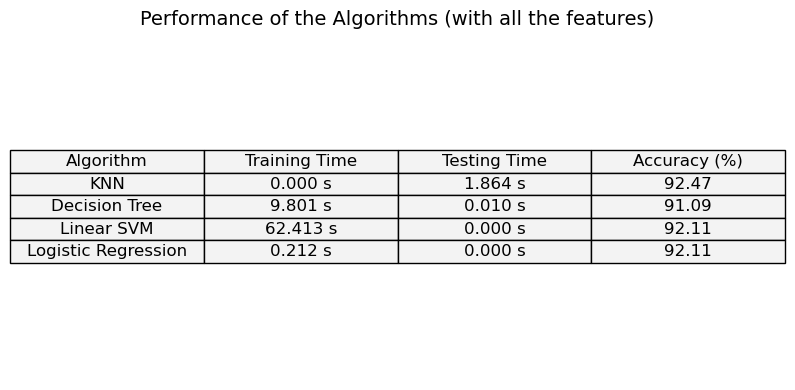

In [37]:
import matplotlib.pyplot as plt

# Define the data
algorithms = ['KNN', 'Decision Tree', 'Linear SVM', 'Logistic Regression']
training_times = [0.0, 9.801, 62.413, 0.212]  
testing_times = [1.864, 0.010, 0.0003, 0.0]      
accuracies = [92.47, 91.09, 92.11, 92.11]     


fig, ax = plt.subplots(figsize=(8, 4))


ax.axis('off')


table_data = []
for algo, train_time, test_time, acc in zip(algorithms, training_times, testing_times, accuracies):
    table_data.append([algo, f"{train_time:.3f} s", f"{test_time:.3f} s", f"{acc:.2f}"])

table = ax.table(cellText=table_data, colLabels=['Algorithm', 'Training Time', 'Testing Time', 'Accuracy (%)'],
                 cellLoc='center', loc='center', cellColours=[['#f3f3f3']*4]*len(table_data), colColours=['#f3f3f3']*4)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)  

plt.title('Performance of the Algorithms (with all the features)', fontsize=14)
plt.tight_layout()
plt.show()



The KNN algorithm is a lazy learning algorithm meaning that it does not directly build a model. It only stores the training data. However, it takes a long time for it to predict a label for a new datapoint. Out of the four implemented algorithms, the KNN algorithm had the highest accuracy of all. <br>
<br>
The Decision tree algorithm is an eager learning algorithm, since it creates a model from the training data before receiving new data to classify or predict. Once built, the decision tree can quickly classify new instances based on the learned structure. Out of the four implemented algorithms, the Decision Tree aglgorithm had the lowest accuracy of all. <br>
<br>
The linear SVM algorithm is an eager learner, which explains why it takes a long time to train. Once the model (the hyperplane) is determined in the training phase, it can be used to classify new instances efficiently. Overall, the accuracy of the linear SVM algorithm was medium in comparison to the other algorithms implemented. <br>
<br>
The Logistic Regression algorithm is another eager learning algorithm. Once the parameters are learned from the training data, logistic regression can quickly classify new instances by computing a weighted sum of the input features and applying the sigmoid function to obtain a probability score. This explains why the training time is higher, and the testing time is very low. Similar the linear SVM algorithm, the logistic algorithm had a medium level accuracy in comparison to the other implemented algorithms.

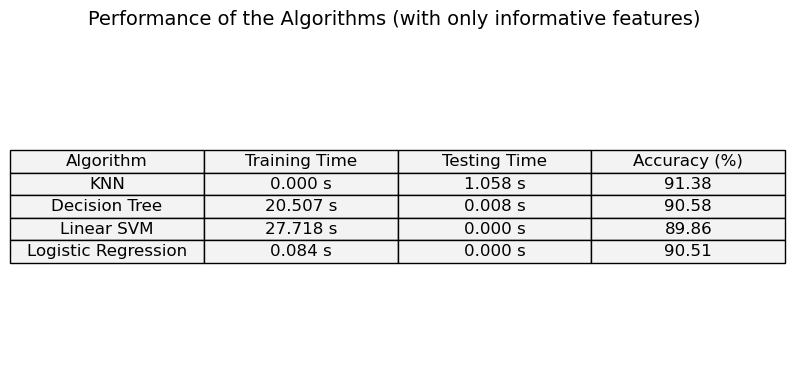

In [40]:
import matplotlib.pyplot as plt


algorithms = ['KNN', 'Decision Tree', 'Linear SVM', 'Logistic Regression']
training_times = [0.0, 20.506963, 27.718, 0.084]  
testing_times = [1.058, 0.008025, 0.0, 0.0]      
accuracies = [91.38, 90.58, 89.86, 90.51]     


fig, ax = plt.subplots(figsize=(8, 4))


ax.axis('off')


table_data = []
for algo, train_time, test_time, acc in zip(algorithms, training_times, testing_times, accuracies):
    table_data.append([algo, f"{train_time:.3f} s", f"{test_time:.3f} s", f"{acc:.2f}"])

table = ax.table(cellText=table_data, colLabels=['Algorithm', 'Training Time', 'Testing Time', 'Accuracy (%)'],
                 cellLoc='center', loc='center', cellColours=[['#f3f3f3']*4]*len(table_data), colColours=['#f3f3f3']*4)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)  

plt.title('Performance of the Algorithms (with only informative features) ', fontsize=14)
plt.tight_layout()
plt.show()


We notice that in general, when we remove the non informative features and implement the algorithms with only the informative features, the test accuracy
tends to decline slightly. However, training and testing times become shorter. Depending on which is more important to us, efficiency or accuracy, we can choose to use either of these methods.